In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plot settings
plt.style.use('default')

In [3]:
customer_df = pd.read_csv("customer_shopping_data.csv.zip")
menu_df = pd.read_csv("menu.csv")

In [4]:
customer_df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


The dataset contains retail customer shopping information including customer demographics, product category, price, payment method, and purchase date.


In [5]:
customer_df.shape

(99457, 10)

In [6]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [7]:
customer_df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

In [8]:
customer_df.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


There are no missing values in the dataset,so no imputation is required.

In [9]:
customer_df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset

In [10]:
customer_df.dtypes

,0
invoice_no,object
customer_id,object
gender,object
age,int64
category,object
quantity,int64
price,float64
payment_method,object
invoice_date,object
shopping_mall,object


In [11]:
customer_df['invoice_date'] = pd.to_datetime(customer_df['invoice_date'])

ValueError: time data "16/05/2021" doesn't match format "%m/%d/%Y", at position 3. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [12]:
customer_df['invoice_date'].head(10)

,invoice_date
0,5/8/2022
1,12/12/2021
2,9/11/2021
3,16/05/2021
4,24/10/2021
5,24/05/2022
6,13/03/2022
7,13/01/2021
8,4/11/2021
9,22/08/2021


In [13]:
customer_df['invoice_date'] = pd.to_datetime(
    customer_df['invoice_date'],
    errors='coerce',
    dayfirst=True
)

In [14]:
customer_df.dtypes

,0
invoice_no,object
customer_id,object
gender,object
age,int64
category,object
quantity,int64
price,float64
payment_method,object
invoice_date,datetime64[ns]
shopping_mall,object


No missing values
No datatypes issues
invoice_date converted to datetime
Dataset ready for analysis

In [15]:
customer_df.describe()

,age,quantity,price,invoice_date
count,99457.000000,99457.000000,99457.000000,99457
mean,43.427089,3.003429,689.256321,2022-02-04 02:46:59.783424
min,18.000000,1.000000,5.230000,2021-01-01 00:00:00
25%,30.000000,2.000000,45.450000,2021-07-19 00:00:00
50%,43.000000,3.000000,203.300000,2022-02-05 00:00:00
75%,56.000000,4.000000,1200.320000,2022-08-22 00:00:00
max,69.000000,5.000000,5250.000000,2023-03-08 00:00:00
std,14.990054,1.413025,941.184567,NaN


In [17]:
# Mean
customer_df['price'].mean()

# Median
customer_df['price'].median()

# Mode
customer_df['price'].mode()

# Standard Deviation
customer_df['price'].std()

941.1845672157425

Descriptive Statistics:
Descriptive statistics were calculated to understand the distribution of numerical variables such as price and quantity. Measures including mean, median, mode, and standard deviation provide insights into customer purchasing behavior.

In [18]:
sales_over_time = customer_df.groupby('invoice_date')['price'].sum()

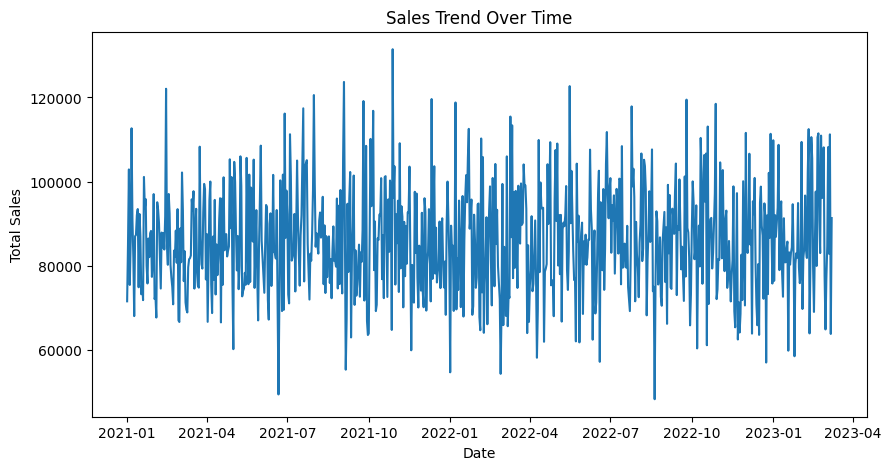

In [19]:
plt.figure(figsize=(10,5))
plt.plot(sales_over_time)
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

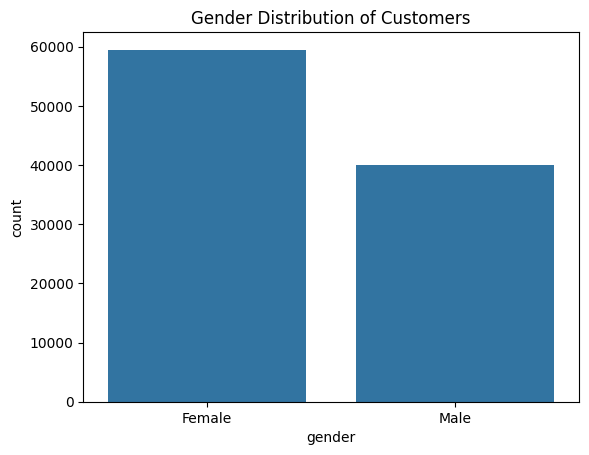

In [20]:
sns.countplot(x='gender', data=customer_df)
plt.title("Gender Distribution of Customers")
plt.show()

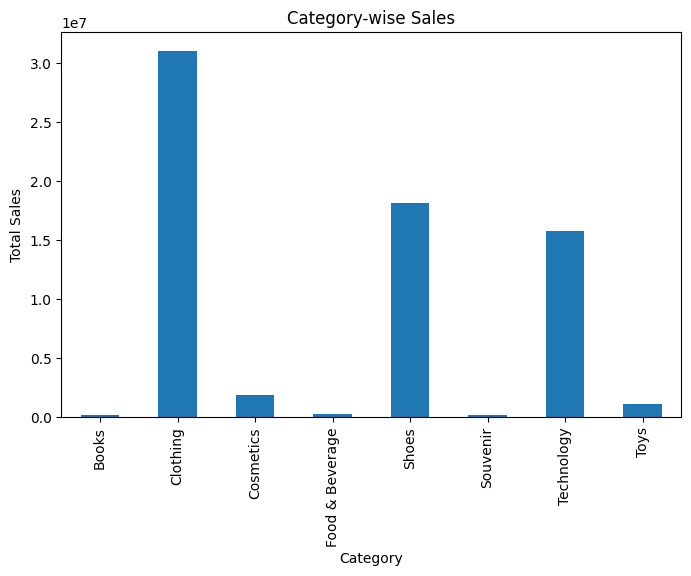

In [21]:
category_sales = customer_df.groupby('category')['price'].sum()

category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

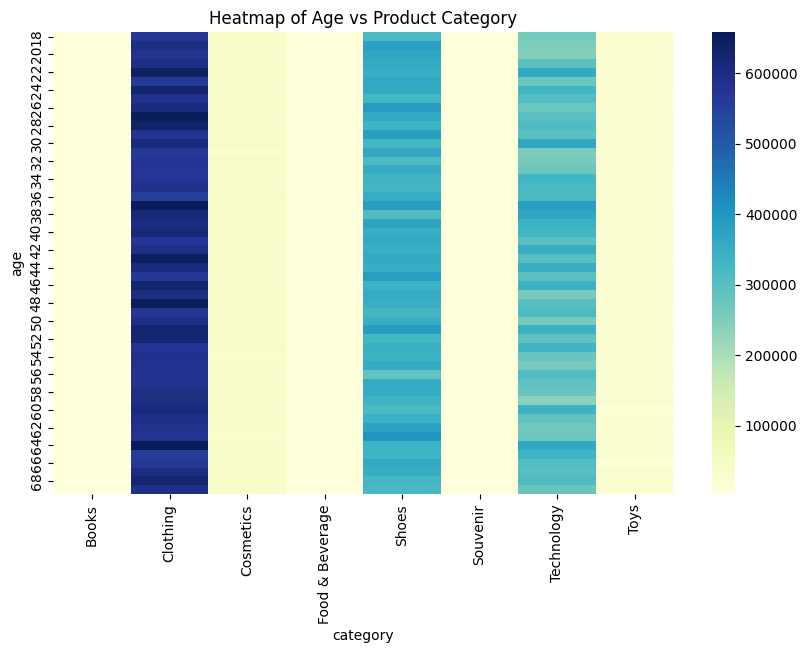

In [22]:
pivot_table = customer_df.pivot_table(
    values='price',
    index='age',
    columns='category',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, cmap='YlGnBu')
plt.title("Heatmap of Age vs Product Category")
plt.show()

Recommendations:
Focus marketing strategies on high-performing product categories.
Target age groups that contribute the highest revenue.
Analyze peak sales periods to improve inventory planning.
Encourage preferred payment methods to enhance customer experience.

Additional Dataset:
An additional dataset (menu.csv) was provided containing product-level information. The primary analysis focuses on customer shopping data, which sufficiently captures retail sales behavior. The menu dataset can be integrated in future work for deeper product-level insights.